In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# PART A — STATIC GRAPHENE DEVICE AND LEADS
# Cell A1: Imports and shared parameters
# ============================================================

# -----------------------------
# Energy unit
# -----------------------------
# All energies are measured in units of graphene hopping gamma.
# Physical graphene: gamma ≈ 2.7 eV.
gamma = 1.0

# -----------------------------
# ZGNR geometry
# -----------------------------
Ny = 29                 # ribbon width; one unit cell has 2*Ny atoms
N_orb = 2 * Ny          # number of orbitals per lead/device slice

# Number of longitudinal unit cells in the finite irradiated region.
#
# Nx = 30 is motivated by the finite-length geometry used in the paper,

Nx = 30

# Total number of orbitals in the central graphene region
N_device = Nx * N_orb

# -----------------------------
# Numerical tolerances
# -----------------------------
eta = 1e-8              # small imaginary broadening for retarded GFs

print("ZGNR width Ny                  =", Ny)
print("Atoms (Orbitals) per longitudinal cell =", N_orb)
print("Number of device cells Nx      =", Nx)
print("Total device orbitals          =", N_device)

ZGNR width Ny                  = 29
Atoms (Orbitals) per longitudinal cell = 58
Number of device cells Nx      = 30
Total device orbitals          = 1740


In [3]:
# ============================================================
# Cell A2: Static ZGNR unit-cell Hamiltonian
# ============================================================

def zgnr_unit_cell(Ny, gamma=1.0):
    """
    Construct the static nearest-neighbor tight-binding matrices
    for a zigzag graphene nanoribbon.

    Returns
    -------
    H00 : ndarray
        Intracell Hamiltonian of one longitudinal ZGNR slice.

    H01 : ndarray
        Coupling from one longitudinal slice to the next.

    Notes
    -----
    One slice contains:
        A_0, B_0, A_1, B_1, ..., A_(Ny-1), B_(Ny-1)

    so its dimension is 2*Ny.
    """

    n_orb = 2 * Ny

    H00 = np.zeros((n_orb, n_orb), dtype=complex)
    H01 = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        """Index of sublattice-A orbital at transverse position j."""
        return 2 * j

    def B(j):
        """Index of sublattice-B orbital at transverse position j."""
        return 2 * j + 1

    # --------------------------------------------------------
    # Nearest-neighbor bonds inside one longitudinal unit cell
    # --------------------------------------------------------

    # A_j <-> B_j
    for j in range(Ny):
        H00[A(j), B(j)] = -gamma
        H00[B(j), A(j)] = -gamma

    # B_j <-> A_(j+1)
    for j in range(Ny - 1):
        H00[A(j + 1), B(j)] = -gamma
        H00[B(j), A(j + 1)] = -gamma

    # --------------------------------------------------------
    # Coupling between neighboring longitudinal unit cells
    # --------------------------------------------------------

    for j in range(Ny):
        H01[A(j), B(j)] = -gamma

    return H00, H01


# Construct the matrices only once
H00, H01 = zgnr_unit_cell(Ny, gamma)

print("H00 shape =", H00.shape)
print("H01 shape =", H01.shape)

print(
    "Hermiticity error of H00 =",
    np.linalg.norm(H00 - H00.conj().T)
)

H00 shape = (58, 58)
H01 shape = (58, 58)
Hermiticity error of H00 = 0.0


In [4]:
# ============================================================
# Cell A3: Finite central graphene region
# ============================================================

def build_finite_zgnr(H00, H01, Nx):
    """
    Construct a finite ZGNR consisting of Nx longitudinal slices.

    Parameters
    ----------
    H00 : ndarray
        Intracell Hamiltonian.

    H01 : ndarray
        Coupling from slice x to slice x+1.

    Nx : int
        Number of longitudinal slices.

    Returns
    -------
    H_device : ndarray
        Static Hamiltonian of the finite central region.
    """

    n_orb = H00.shape[0]
    n_total = Nx * n_orb

    H_device = np.zeros(
        (n_total, n_total),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_device[sl_x, sl_x] = H00

    # Couplings between neighboring longitudinal slices
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_device[sl_x, sl_next] = H01
        H_device[sl_next, sl_x] = H01.conj().T

    return H_device


H_device_static = build_finite_zgnr(
    H00,
    H01,
    Nx
)

# ------------------------------------------------------------
# Contact orbitals
# ------------------------------------------------------------
# The first longitudinal slice couples to the left lead.
left_contact = np.arange(
    0,
    N_orb
)

# The last longitudinal slice couples to the right lead.
right_contact = np.arange(
    (Nx - 1) * N_orb,
    Nx * N_orb
)

print("Static device shape =", H_device_static.shape)

print(
    "Device Hermiticity error =",
    np.linalg.norm(
        H_device_static
        - H_device_static.conj().T
    )
)

print("Number of left-contact orbitals  =", len(left_contact))
print("Number of right-contact orbitals =", len(right_contact))

Static device shape = (1740, 1740)
Device Hermiticity error = 0.0
Number of left-contact orbitals  = 58
Number of right-contact orbitals = 58


In [5]:
# ============================================================
# Cell A3G1 (corrected) — run this ENTIRE cell before A3G2
# ============================================================
def generate_zgnr_coordinates(Nx, Ny):
    n_orb = 2 * Ny
    n_device = Nx * n_orb
    coords = np.zeros((n_device, 2), dtype=float)
    sublattice = np.empty(n_device, dtype="<U1")
    cell_index = np.zeros(n_device, dtype=int)
    transverse_index = np.zeros(n_device, dtype=int)

    # corrected, self-consistent bond vectors (d2 = A(j+1)-B(j))
    d1 = np.array([np.sqrt(3.0) / 2.0,  0.5])
    d2 = np.array([0.0,                -1.0])
    d3 = np.array([-np.sqrt(3.0) / 2.0, 0.5])

    transverse_step   = d2 - d1
    longitudinal_step = d1 - d3

    def A(j): return 2 * j
    def B(j): return 2 * j + 1

    for x in range(Nx):
        for j in range(Ny):
            rA = x * longitudinal_step + j * transverse_step
            rB = rA - d1
            idxA = x * n_orb + A(j); idxB = x * n_orb + B(j)
            coords[idxA] = rA; coords[idxB] = rB
            sublattice[idxA] = "A"; sublattice[idxB] = "B"
            cell_index[idxA] = x; cell_index[idxB] = x
            transverse_index[idxA] = j; transverse_index[idxB] = j
    return coords, sublattice, cell_index, transverse_index

# THIS LINE is the one that actually rebuilds coords_device --
# it must be re-run every time the function above changes, or every
# time Nx/Ny change, or coords_device silently goes stale.
coords_device, sublattice_device, cell_device, j_device = generate_zgnr_coordinates(
    Nx=Nx, Ny=Ny
)
print("Coordinate array shape =", coords_device.shape, " (expect", Nx*2*Ny, ")")

Coordinate array shape = (1740, 2)  (expect 1740 )


In [6]:
# ============================================================
# Cell A3G1b: rebuild all Nx/Ny-dependent objects from scratch
# Run this FIRST whenever Nx or Ny changes.
# ============================================================
H00, H01 = zgnr_unit_cell(Ny, gamma)
n_orb = 2 * Ny

coords_device, sublattice_device, cell_device, j_device = generate_zgnr_coordinates(
    Nx=Nx, Ny=Ny
)

print("Ny =", Ny, " Nx =", Nx)
print("H00 shape           =", H00.shape)
print("coords_device shape =", coords_device.shape, " expected =", (Nx*n_orb, 2))

Ny = 29  Nx = 30
H00 shape           = (58, 58)
coords_device shape = (1740, 2)  expected = (1740, 2)


In [7]:
# ============================================================
# Cell A3G2 (updated): Coordinate / Hamiltonian bond-direction check
# ============================================================

def A(j):
    return 2 * j

def B(j):
    return 2 * j + 1


n_orb = 2 * Ny

# updated to match the corrected (rotated) vectors in A3G1
d1_used = np.array([np.sqrt(3.0) / 2.0,  0.5])
d2_used = np.array([0.0,                -1.0])
d3_used = np.array([-np.sqrt(3.0) / 2.0, 0.5])


# Choose an interior transverse site
j_test = 0
x_test = 0

# ------------------------------------------------------------
# Bond 1: H00[A(j), B(j)]
# ------------------------------------------------------------
idx_Aj = x_test * n_orb + A(j_test)
idx_Bj = x_test * n_orb + B(j_test)
d1_actual = coords_device[idx_Aj] - coords_device[idx_Bj]

# ------------------------------------------------------------
# Bond 2: H00[A(j+1), B(j)]
# ------------------------------------------------------------
idx_Ajp1 = x_test * n_orb + A(j_test + 1)
d2_actual = coords_device[idx_Ajp1] - coords_device[idx_Bj]

# ------------------------------------------------------------
# Bond 3: H01[A(j), B(j)]  ->  H_{A_j(x), B_j(x+1)}
# ------------------------------------------------------------
idx_Bj_next = (x_test + 1) * n_orb + B(j_test)
d3_actual = coords_device[idx_Aj] - coords_device[idx_Bj_next]

print("d1 actual =", d1_actual, " used =", d1_used, " error =", np.linalg.norm(d1_actual - d1_used))
print("d2 actual =", d2_actual, " used =", d2_used, " error =", np.linalg.norm(d2_actual - d2_used))
print("d3 actual =", d3_actual, " used =", d3_used, " error =", np.linalg.norm(d3_actual - d3_used))

d1 actual = [0.8660254 0.5      ]  used = [0.8660254 0.5      ]  error = 0.0
d2 actual = [ 0. -1.]  used = [ 0. -1.]  error = 0.0
d3 actual = [-0.8660254  0.5      ]  used = [-0.8660254  0.5      ]  error = 0.0


In [8]:
# ============================================================
# Cell A3G2b (optional, stronger check): verify EVERY bond in
# H00/H01 against coords_device, for every unit cell
# ============================================================
max_err = 0.0
n_checked = 0

ii0, kk0 = np.nonzero(np.triu(H00, k=1))   # every intracell hopping
ii1, kk1 = np.nonzero(H01)                  # every intercell hopping

for x in range(Nx):
    for i, k in zip(ii0, kk0):
        d = np.linalg.norm(coords_device[x*n_orb+i] - coords_device[x*n_orb+k])
        max_err = max(max_err, abs(d - 1.0))
        n_checked += 1
    if x < Nx - 1:
        for i, k in zip(ii1, kk1):
            d = np.linalg.norm(coords_device[x*n_orb+i] - coords_device[(x+1)*n_orb+k])
            max_err = max(max_err, abs(d - 1.0))
            n_checked += 1

print(f"checked {n_checked} bonds across all {Nx} unit cells")
print("max |bond length - 1| =", max_err)

checked 2551 bonds across all 30 unit cells
max |bond length - 1| = 1.021405182655144e-14


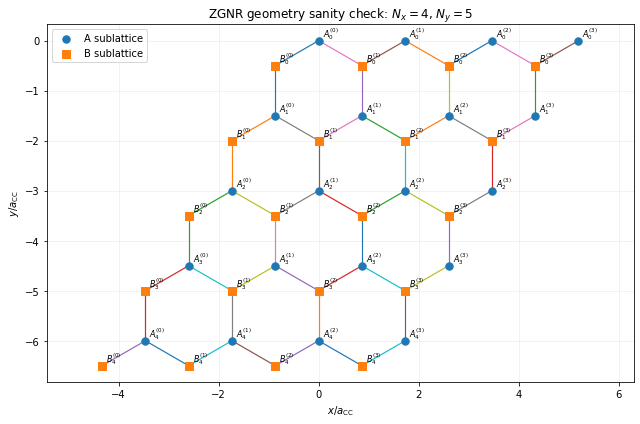

In [9]:
# ============================================================
# Cell A3G3: Small ZGNR geometry sanity plot
#
# Plot a reduced ribbon first so that the atomic arrangement,
# A/B sublattices, and Hamiltonian bonds can be inspected clearly.
# ============================================================

Nx_plot = 4
Ny_plot = 5

coords_plot, sublattice_plot, cell_plot, j_plot = (
    generate_zgnr_coordinates(
        Nx=Nx_plot,
        Ny=Ny_plot
    )
)

n_orb_plot = 2 * Ny_plot

def A(j):
    return 2 * j

def B(j):
    return 2 * j + 1


plt.figure(figsize=(9, 6))

# ------------------------------------------------------------
# Draw bonds exactly according to the Hamiltonian connectivity
# ------------------------------------------------------------

# Bond type 1:
# A_j(x) <-> B_j(x)
for x in range(Nx_plot):
    for j in range(Ny_plot):

        iA = x * n_orb_plot + A(j)
        iB = x * n_orb_plot + B(j)

        plt.plot(
            [coords_plot[iA, 0], coords_plot[iB, 0]],
            [coords_plot[iA, 1], coords_plot[iB, 1]],
            "-",
            lw=1.2
        )

# Bond type 2:
# B_j(x) <-> A_(j+1)(x)
for x in range(Nx_plot):
    for j in range(Ny_plot - 1):

        iB = x * n_orb_plot + B(j)
        iA_next = x * n_orb_plot + A(j + 1)

        plt.plot(
            [coords_plot[iB, 0], coords_plot[iA_next, 0]],
            [coords_plot[iB, 1], coords_plot[iA_next, 1]],
            "-",
            lw=1.2
        )

# Bond type 3:
# A_j(x) <-> B_j(x+1)
for x in range(Nx_plot - 1):
    for j in range(Ny_plot):

        iA = x * n_orb_plot + A(j)
        iB_next = (x + 1) * n_orb_plot + B(j)

        plt.plot(
            [coords_plot[iA, 0], coords_plot[iB_next, 0]],
            [coords_plot[iA, 1], coords_plot[iB_next, 1]],
            "-",
            lw=1.2
        )

# ------------------------------------------------------------
# Plot A and B sublattices separately
# ------------------------------------------------------------

mask_A = (sublattice_plot == "A")
mask_B = (sublattice_plot == "B")

plt.scatter(
    coords_plot[mask_A, 0],
    coords_plot[mask_A, 1],
    s=55,
    label="A sublattice",
    zorder=3
)

plt.scatter(
    coords_plot[mask_B, 0],
    coords_plot[mask_B, 1],
    s=55,
    marker="s",
    label="B sublattice",
    zorder=3
)

# ------------------------------------------------------------
# Label sites for this small diagnostic geometry
# ------------------------------------------------------------

for idx in range(len(coords_plot)):

    x = cell_plot[idx]
    j = j_plot[idx]
    sub = sublattice_plot[idx]

    plt.text(
        coords_plot[idx, 0] + 0.08,
        coords_plot[idx, 1] + 0.08,
        rf"${sub}_{{{j}}}^{{({x})}}$",
        fontsize=8
    )

plt.xlabel(r"$x/a_{\rm CC}$")
plt.ylabel(r"$y/a_{\rm CC}$")

plt.title(
    rf"ZGNR geometry sanity check: "
    rf"$N_x={Nx_plot}$, $N_y={Ny_plot}$"
)

plt.axis("equal")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

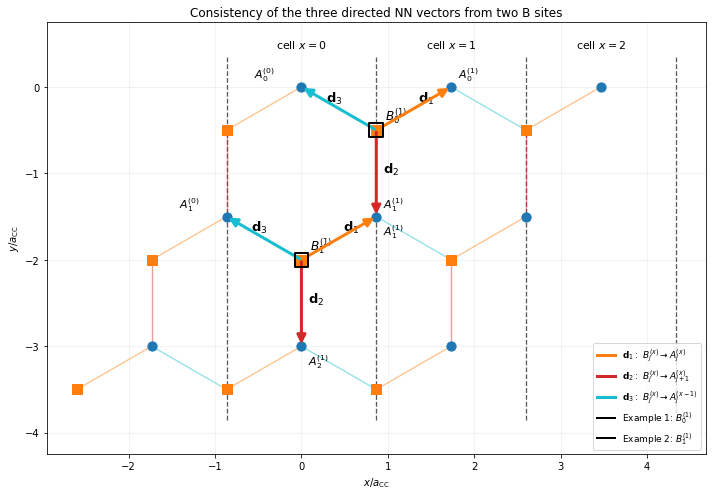

In [10]:
# ============================================================
# Cell A3G4:
# Consistency of the three directed NN bond vectors
# from TWO different B sites
#
# General rule:
#
#   d1 : B_j(x) -> A_j(x)
#   d2 : B_j(x) -> A_(j+1)(x)
#   d3 : B_j(x) -> A_j(x-1)
#
# First reference:
#   B_0^(1)
#
# Second reference:
#   B_1^(1)
# ============================================================

Nx_zoom = 3
Ny_zoom = 3

coords_zoom, sub_zoom, cell_zoom, j_zoom = (
    generate_zgnr_coordinates(
        Nx=Nx_zoom,
        Ny=Ny_zoom
    )
)

n_orb_zoom = 2 * Ny_zoom


def A(j):
    return 2 * j


def B(j):
    return 2 * j + 1


fig, ax = plt.subplots(figsize=(10, 7))


# ------------------------------------------------------------
# Fixed colors for the three bond families
# ------------------------------------------------------------

color_d1 = "tab:orange"
color_d2 = "tab:red"
color_d3 = "tab:cyan"


# ============================================================
# 1. Draw all physical NN bonds in the small ribbon
# ============================================================

# d1 family:
# A_j(x) <-> B_j(x)
for x in range(Nx_zoom):
    for j in range(Ny_zoom):

        iA = x * n_orb_zoom + A(j)
        iB = x * n_orb_zoom + B(j)

        ax.plot(
            [coords_zoom[iA, 0], coords_zoom[iB, 0]],
            [coords_zoom[iA, 1], coords_zoom[iB, 1]],
            color=color_d1,
            lw=1.4,
            alpha=0.45
        )


# d2 family:
# B_j(x) <-> A_(j+1)(x)
for x in range(Nx_zoom):
    for j in range(Ny_zoom - 1):

        iB = x * n_orb_zoom + B(j)
        iA_next = x * n_orb_zoom + A(j + 1)

        ax.plot(
            [coords_zoom[iB, 0], coords_zoom[iA_next, 0]],
            [coords_zoom[iB, 1], coords_zoom[iA_next, 1]],
            color=color_d2,
            lw=1.4,
            alpha=0.45
        )


# d3 family:
# A_j(x) <-> B_j(x+1)
for x in range(Nx_zoom - 1):
    for j in range(Ny_zoom):

        iA = x * n_orb_zoom + A(j)
        iB_next = (x + 1) * n_orb_zoom + B(j)

        ax.plot(
            [coords_zoom[iA, 0], coords_zoom[iB_next, 0]],
            [coords_zoom[iA, 1], coords_zoom[iB_next, 1]],
            color=color_d3,
            lw=1.4,
            alpha=0.45
        )


# ============================================================
# 2. Plot A and B atoms
# ============================================================

mask_A = (sub_zoom == "A")
mask_B = (sub_zoom == "B")

ax.scatter(
    coords_zoom[mask_A, 0],
    coords_zoom[mask_A, 1],
    s=85,
    marker="o",
    label="A sublattice",
    zorder=4
)

ax.scatter(
    coords_zoom[mask_B, 0],
    coords_zoom[mask_B, 1],
    s=85,
    marker="s",
    label="B sublattice",
    zorder=4
)


# ============================================================
# Helper function:
# draw d1,d2,d3 from one chosen B_j^(x)
# ============================================================

def draw_three_vectors_from_B(
    ax,
    x0,
    j0,
    linestyle="-",
    label_prefix=""
):

    # --------------------------------------------------------
    # Common B origin
    # --------------------------------------------------------

    iB = x0 * n_orb_zoom + B(j0)

    # d1 endpoint:
    # A_j(x)
    iA_d1 = x0 * n_orb_zoom + A(j0)

    # d2 endpoint:
    # A_(j+1)(x)
    iA_d2 = x0 * n_orb_zoom + A(j0 + 1)

    # d3 endpoint:
    # A_j(x-1)
    iA_d3 = (x0 - 1) * n_orb_zoom + A(j0)

    rB = coords_zoom[iB]

    rA_d1 = coords_zoom[iA_d1]
    rA_d2 = coords_zoom[iA_d2]
    rA_d3 = coords_zoom[iA_d3]


    # --------------------------------------------------------
    # Draw d1
    # --------------------------------------------------------

    ax.annotate(
        "",
        xy=rA_d1,
        xytext=rB,
        arrowprops=dict(
            arrowstyle="-|>",
            lw=3,
            color=color_d1,
            linestyle=linestyle,
            mutation_scale=18
        ),
        zorder=6
    )


    # --------------------------------------------------------
    # Draw d2
    # --------------------------------------------------------

    ax.annotate(
        "",
        xy=rA_d2,
        xytext=rB,
        arrowprops=dict(
            arrowstyle="-|>",
            lw=3,
            color=color_d2,
            linestyle=linestyle,
            mutation_scale=18
        ),
        zorder=6
    )


    # --------------------------------------------------------
    # Draw d3
    # --------------------------------------------------------

    ax.annotate(
        "",
        xy=rA_d3,
        xytext=rB,
        arrowprops=dict(
            arrowstyle="-|>",
            lw=3,
            color=color_d3,
            linestyle=linestyle,
            mutation_scale=18
        ),
        zorder=6
    )


    # ========================================================
    # Label common B origin
    # ========================================================

    ax.scatter(
        [rB[0]],
        [rB[1]],
        s=190,
        marker="s",
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        zorder=7
    )

    ax.text(
        rB[0] + 0.10,
        rB[1] + 0.12,
        rf"$B_{{{j0}}}^{{({x0})}}$",
        fontsize=12,
        fontweight="bold"
    )


    # ========================================================
    # Label the THREE connected A endpoints
    # ========================================================

    ax.text(
        rA_d1[0] + 0.08,
        rA_d1[1] + 0.10,
        rf"$A_{{{j0}}}^{{({x0})}}$",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        rA_d2[0] + 0.08,
        rA_d2[1] - 0.22,
        rf"$A_{{{j0 + 1}}}^{{({x0})}}$",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        rA_d3[0] - 0.55,
        rA_d3[1] + 0.10,
        rf"$A_{{{j0}}}^{{({x0 - 1})}}$",
        fontsize=11,
        fontweight="bold"
    )


    # ========================================================
    # Label d1,d2,d3 near their arrows
    # ========================================================

    mid1 = 0.5 * (rB + rA_d1)
    mid2 = 0.5 * (rB + rA_d2)
    mid3 = 0.5 * (rB + rA_d3)

    ax.text(
        mid1[0] + 0.05,
        mid1[1] + 0.08,
        rf"$\mathbf{{d}}_1$",
        fontsize=13
    )

    ax.text(
        mid2[0] + 0.08,
        mid2[1],
        rf"$\mathbf{{d}}_2$",
        fontsize=13
    )

    ax.text(
        mid3[0] - 0.15,
        mid3[1] + 0.08,
        rf"$\mathbf{{d}}_3$",
        fontsize=13
    )


# ============================================================
# 3. First common origin:
#
# B_0^(1)
#
# Expected:
#   d1 -> A_0^(1)
#   d2 -> A_1^(1)
#   d3 -> A_0^(0)
# ============================================================

draw_three_vectors_from_B(
    ax=ax,
    x0=1,
    j0=0,
    linestyle="-"
)


# ============================================================
# 4. Second common origin:
#
# B_1^(1)
#
# Expected:
#   d1 -> A_1^(1)
#   d2 -> A_2^(1)
#   d3 -> A_1^(0)
#
# Use dashed arrows to distinguish this second example.
# ============================================================

draw_three_vectors_from_B(
    ax=ax,
    x0=1,
    j0=1,
    linestyle="-"
)


# ============================================================
# 5. Legend
# ============================================================

from matplotlib.lines import Line2D

legend_items = [

    Line2D(
        [0], [0],
        color=color_d1,
        lw=3,
        label=r"$\mathbf{d}_1:\ B_j^{(x)}\rightarrow A_j^{(x)}$"
    ),

    Line2D(
        [0], [0],
        color=color_d2,
        lw=3,
        label=r"$\mathbf{d}_2:\ B_j^{(x)}\rightarrow A_{j+1}^{(x)}$"
    ),

    Line2D(
        [0], [0],
        color=color_d3,
        lw=3,
        label=r"$\mathbf{d}_3:\ B_j^{(x)}\rightarrow A_j^{(x-1)}$"
    ),

    Line2D(
        [0], [0],
        color="black",
        lw=2,
        linestyle="-",
        label=r"Example 1: $B_0^{(1)}$"
    ),

    Line2D(
        [0], [0],
        color="black",
        lw=2,
        linestyle="-",
        label=r"Example 2: $B_1^{(1)}$"
    )
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=9
)


# ============================================================
# 6. Show longitudinal unit-cell boundaries
#
# The longitudinal translation is
#
#     T_x = (sqrt(3), 0)
#
# so neighboring cells are displaced horizontally by sqrt(3).
#
# We place each dashed boundary halfway between the reference
# positions of neighboring longitudinal cells.
# ============================================================

longitudinal_period = np.sqrt(3.0)

# x-coordinate of A_0 in cell x=0
x_reference = coords_zoom[A(0), 0]

# Boundaries between cells:
#
#   x = 0 | x = 1 | x = 2
#
# and also the outer left/right boundaries.
cell_boundaries = [
    x_reference
    + (x - 0.5) * longitudinal_period
    for x in range(Nx_zoom + 1)
]

# Vertical extent of the lattice
ymin = coords_zoom[:, 1].min() - 0.35
ymax = coords_zoom[:, 1].max() + 0.35


# ------------------------------------------------------------
# Draw vertical dashed boundaries
# ------------------------------------------------------------

for xb in cell_boundaries:

    ax.vlines(
        xb,
        ymin,
        ymax,
        colors="black",
        linestyles="--",
        linewidth=1.3,
        alpha=0.65,
        zorder=0
    )


# ------------------------------------------------------------
# Label each longitudinal cell
# ------------------------------------------------------------

for x in range(Nx_zoom):

    x_left = cell_boundaries[x]
    x_right = cell_boundaries[x + 1]

    x_center = 0.5 * (x_left + x_right)

    ax.text(
        x_center,
        ymax + 0.08,
        rf"cell $x={x}$",
        ha="center",
        va="bottom",
        fontsize=11
    )


# ============================================================
# Formatting
# ============================================================

ax.set_xlabel(r"$x/a_{\rm CC}$")
ax.set_ylabel(r"$y/a_{\rm CC}$")

ax.set_title(
    "Consistency of the three directed NN vectors "
    "from two B sites"
)

ax.axis("equal")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Directed nearest-neighbor bond vectors and longitudinal unit cells

This figure visualizes the three nearest-neighbor bond vectors used in the
graphene tight-binding Hamiltonian and, later, in the Peierls substitution.

The superscript $x$ labels the **longitudinal unit cell**, while the
subscript $j$ labels the position across the ribbon width. Thus,

$A_j^{(x)},\qquad B_j^{(x)}$

denote A- and B-sublattice sites with transverse index \(j\) belonging to
longitudinal cell \(x\).

The vertical dashed lines indicate the boundaries between neighboring
longitudinal unit cells.

### Three directed nearest-neighbor vectors

For any B-sublattice site $B_j^{(x)}$, the three nearest A-sublattice
neighbors are reached through

$\boxed{
\mathbf d_1:\quad
B_j^{(x)}
\rightarrow
A_j^{(x)}
}$


$\boxed{
\mathbf d_1:\quad
B_j^{(x)}
\rightarrow
A_j^{(x)}
}$


$\boxed{
\mathbf d_3:\quad
B_j^{(x)}
\rightarrow
A_j^{(x-1)}
}$


In the rotated plotting convention used here,

$\mathbf d_1=
\left(
\frac{\sqrt{3}}{2},
\frac{1}{2}
\right),$

$\mathbf d_2=
(0,-1),$

and

$\mathbf d_3=
\left(
-\frac{\sqrt{3}}{2},
\frac{1}{2}
\right).$

All three vectors have the same nearest-neighbor bond length,

$
|\mathbf d_1| =$
$|\mathbf d_2|=$
$|\mathbf d_3|$
$=a_{\rm CC},
$

and they are separated by $120^\circ$, as required for the honeycomb
lattice.

### Relation to the Hamiltonian blocks

The first two bonds connect atoms belonging to the **same longitudinal
cell**:

$\mathbf d_1:
\quad
B_j^{(x)}
\rightarrow
A_j^{(x)},$

$\mathbf d_2:
\quad
B_j^{(x)}
\rightarrow
A_{j+1}^{(x)}.$

Therefore these bonds are contained in the intracell Hamiltonian block

$H_{00}.$

The third bond connects neighboring longitudinal cells:

$\mathbf d_3:
\quad
B_j^{(x)}
\rightarrow
A_j^{(x-1)}.$

Therefore this bond is represented by the intercell coupling
$H_{01}$ (or its Hermitian conjugate, depending on the hopping
direction).

### Consistency check shown in the figure

Two different B sites are used to demonstrate that the same connectivity
rule repeats throughout the ribbon.

For the first example,

$B_0^{(1)}$

has the three nearest neighbors


$\mathbf d_1:
\quad
B_0^{(1)}
\rightarrow
A_0^{(1)},$

$\mathbf d_2:
\quad
B_0^{(1)}
\rightarrow
A_1^{(1)},$

$\mathbf d_3:
\quad
B_0^{(1)}
\rightarrow
A_0^{(0)}.$

For the second example,

$B_1^{(1)}$

has

$\mathbf d_1:
\quad
B_1^{(1)}
\rightarrow
A_1^{(1)},$

$\mathbf d_2:
\quad
B_1^{(1)}
\rightarrow
A_2^{(1)},$

$\mathbf d_3:
\quad
B_1^{(1)}
\rightarrow
A_1^{(0)}.$

Thus the figure provides a direct geometrical check that the same three
nearest-neighbor bond rules are repeated consistently throughout the ZGNR.

### Connection to the driven Hamiltonian

In the irradiated graphene region, these directed bond vectors determine
the bond-dependent Peierls phase,

$t_{ij}(t)=$
$-\gamma
\exp\left[
i\,\mathbf A(t)\cdot\mathbf d_{ij}
\right],$

up to the dimensionless prefactor used in the numerical implementation.

Therefore, the direction of each $\mathbf d_i$ is physically important:
different graphene bonds acquire different time-dependent phases under the
same electromagnetic vector potential.

the two following cells are built to chekc the inversion symmtery of the unirradiated device

In [11]:
# ============================================================
# ONE SELF-CONTAINED CELL -- (re)defines everything and rebuilds
# it fresh every time it's run. Run this cell FIRST, and re-run
# it any time you change Nx, Ny, or gamma -- nothing downstream
# will go stale as long as you do that.
# ============================================================
import numpy as np

# ---------- A1: parameters ----------
gamma = 1.0
Ny = 29                  # ribbon width (number of zigzag rows)
Nx = 30                  # device length (number of unit cells)
n_orb = 2 * Ny
n_device = Nx * n_orb
eta = 1e-8

# ---------- A2: static per-slice Hamiltonian ----------
def zgnr_unit_cell(Ny, gamma=1.0):
    n_orb = 2 * Ny
    H00 = np.zeros((n_orb, n_orb), dtype=complex)
    H01 = np.zeros((n_orb, n_orb), dtype=complex)
    def A(j): return 2 * j
    def B(j): return 2 * j + 1
    for j in range(Ny):
        H00[A(j), B(j)] = -gamma
        H00[B(j), A(j)] = -gamma
    for j in range(Ny - 1):
        H00[A(j+1), B(j)] = -gamma
        H00[B(j), A(j+1)] = -gamma
    for j in range(Ny):
        H01[A(j), B(j)] = -gamma
    return H00, H01

# ---------- A3: finite device Hamiltonian ----------
def build_finite_zgnr(H00, H01, Nx):
    n_orb = H00.shape[0]
    n_total = Nx * n_orb
    H = np.zeros((n_total, n_total), dtype=complex)
    for x in range(Nx):
        sl = slice(x*n_orb, (x+1)*n_orb)
        H[sl, sl] = H00
    for x in range(Nx - 1):
        sl  = slice(x*n_orb, (x+1)*n_orb)
        sln = slice((x+1)*n_orb, (x+2)*n_orb)
        H[sl, sln] = H01
        H[sln, sl] = H01.conj().T
    return H

# ---------- A3G1: atomic coordinates (corrected, self-consistent) ----------
def generate_zgnr_coordinates(Nx, Ny):
    n_orb = 2 * Ny
    n_device = Nx * n_orb
    coords = np.zeros((n_device, 2), dtype=float)
    sublattice = np.empty(n_device, dtype="<U1")
    cell_index = np.zeros(n_device, dtype=int)
    transverse_index = np.zeros(n_device, dtype=int)

    # d_k = r_A - r_B convention; d2 = A(j+1)-B(j) (NOT B(j)-A(j+1))
    d1 = np.array([np.sqrt(3.0) / 2.0,  0.5])
    d2 = np.array([0.0,                -1.0])
    d3 = np.array([-np.sqrt(3.0) / 2.0, 0.5])
    transverse_step   = d2 - d1
    longitudinal_step = d1 - d3

    def A(j): return 2 * j
    def B(j): return 2 * j + 1

    for x in range(Nx):
        for j in range(Ny):
            rA = x * longitudinal_step + j * transverse_step
            rB = rA - d1
            idxA, idxB = x*n_orb + A(j), x*n_orb + B(j)
            coords[idxA] = rA; coords[idxB] = rB
            sublattice[idxA] = "A"; sublattice[idxB] = "B"
            cell_index[idxA] = x; cell_index[idxB] = x
            transverse_index[idxA] = j; transverse_index[idxB] = j
    return coords, sublattice, cell_index, transverse_index

# ---------- REBUILD everything fresh, right now, for the CURRENT Nx, Ny ----------
H00, H01 = zgnr_unit_cell(Ny, gamma)
H_device_static = build_finite_zgnr(H00, H01, Nx)

left_contact  = np.arange(0, n_orb)
right_contact = np.arange((Nx-1)*n_orb, Nx*n_orb)

coords_device, sublattice_device, cell_device, j_device = generate_zgnr_coordinates(Nx, Ny)

# ---------- sanity printout: check EVERYTHING agrees with current Nx, Ny ----------
print(f"Ny={Ny}  Nx={Nx}  n_orb={n_orb}  n_device={n_device}")
print("H00 shape             =", H00.shape,             " expected =", (n_orb, n_orb))
print("H_device_static shape =", H_device_static.shape, " expected =", (n_device, n_device))
print("coords_device shape   =", coords_device.shape,   " expected =", (n_device, 2))
print("Hermiticity error of H_device_static =",
      np.linalg.norm(H_device_static - H_device_static.conj().T))
assert H00.shape == (n_orb, n_orb)
assert H_device_static.shape == (n_device, n_device)
assert coords_device.shape == (n_device, 2)
print("\nAll objects rebuilt and consistent with Nx =", Nx, ", Ny =", Ny, "-- safe to proceed.")

Ny=29  Nx=30  n_orb=58  n_device=1740
H00 shape             = (58, 58)  expected = (58, 58)
H_device_static shape = (1740, 1740)  expected = (1740, 1740)
coords_device shape   = (1740, 2)  expected = (1740, 2)
Hermiticity error of H_device_static = 0.0

All objects rebuilt and consistent with Nx = 30 , Ny = 29 -- safe to proceed.


## Static inversion-symmetry check of the finite ZGNR device

The purpose of this cell is to determine whether the **finite central graphene device itself, before applying light**, possesses spatial inversion symmetry.

For the present geometry,

- $N_x=30$ longitudinal cells,
- $N_y=29$,
- $2N_y=58$ carbon orbitals per longitudinal cell,
- and $N_{\mathrm{device}}=1740$ total carbon orbitals.

The test does **not assume an inversion mapping in advance**. Instead, the inversion operation is constructed directly from the real-space atomic coordinates generated for the finite ZGNR.

The candidate inversion center obtained from the geometry is

$$
\mathbf r_c=(12.55736835,\,-21.25).
$$

Spatial inversion about this point acts on every atomic coordinate as

$$
\mathbf r_i
\longrightarrow
\mathbf r_i'
=
2\mathbf r_c-\mathbf r_i.
$$

The code then performs three independent checks.

---

### 1. Geometrical inversion of all atomic sites

For every carbon atom at position $\mathbf r_i$, the code calculates its inverted position

$$
\mathbf r_i'
=
2\mathbf r_c-\mathbf r_i
$$

and searches for a carbon atom of the finite device at that position.

The result is

$$
\text{maximum coordinate matching error}
=
1.07\times10^{-14},
$$

and

$$
1740/1740
$$

sites have unique inversion partners.

Therefore, every carbon atom of the finite device is mapped onto another carbon atom of the same finite device under inversion.

The residual coordinate error of order $10^{-14}$ is only floating-point numerical precision.

Thus, geometrically,

$$
\boxed{
\mathcal P:\{\mathbf r_i\}\rightarrow\{\mathbf r_i\}
}
$$

for the complete finite ZGNR.

---

### 2. Inversion must be an involution: $P^2=I$

The site-to-site inversion mapping defines a permutation operator $P$.

A true spatial inversion performed twice must return every atom to its original position:

$$
\mathcal P^2\mathbf r_i=\mathbf r_i.
$$

Therefore, in the orbital basis, the corresponding permutation matrix must satisfy

$$
P^2=I.
$$

The numerical results are

$$
\text{Permutation involution error}=0,
$$

$$
\|P^2-I\|=0,
$$

and

$$
\|P^\dagger P-I\|=0.
$$

Therefore, the constructed operator is an exact one-to-one inversion permutation of the finite lattice:

$$
\boxed{P^2=I}
$$

and

$$
\boxed{P^\dagger P=I}.
$$

---

### 3. The static Hamiltonian must be invariant under inversion

Geometrical symmetry of the atomic positions alone is not sufficient.

The tight-binding Hamiltonian must also remain unchanged when all orbitals are transformed by the inversion operator.

For the static finite-device Hamiltonian $H_{\mathrm{static}}$, inversion symmetry requires

$$
\boxed{
P H_{\mathrm{static}} P^\dagger
=
H_{\mathrm{static}}
}.
$$

The code therefore constructs

$$
H_{\mathrm{inv}}
=
P H_{\mathrm{static}}P^\dagger
$$

and compares it element by element with the original Hamiltonian.

The result is

$$
\text{absolute inversion error}=0,
$$

and

$$
\text{relative inversion error}=0.
$$

Therefore,

$$
\boxed{
P H_{\mathrm{static}} P^\dagger
=
H_{\mathrm{static}}
}
$$

is satisfied exactly within numerical precision.

---

### Conclusion

All three required tests are satisfied:

$$
\boxed{
\begin{aligned}
&\text{1. Every atomic site has an inversion partner,}\\[2mm]
&\text{2. }P^2=I,\\[2mm]
&\text{3. }PH_{\mathrm{static}}P^\dagger
   =H_{\mathrm{static}}.
\end{aligned}
}
$$

Therefore, the finite central ZGNR used in the calculation is **inversion symmetric in the absence of light**:

$$
\boxed{
\text{Finite static ZGNR device has inversion symmetry.}
}
$$

This establishes the symmetry of the **central graphene device itself**.

It does not yet establish the inversion symmetry of the complete open transport system. For that, the left and right contacts/leads must also transform correctly under inversion, in particular with the left and right sides exchanged:

$$
\boxed{
\mathcal P:\quad L\leftrightarrow R.
}
$$

That lead-device-lead symmetry should be checked separately before using inversion symmetry to analyze the harmonic-current selection rules.

In [12]:
# ============================================================
# Cell A3INV: Static inversion-symmetry test
#
# Checks inversion symmetry of the FINITE graphene device
# with NO light:
#
#       r_i  ->  2 r_c - r_i
#
# and
#
#       P H_static P^\dagger = H_static
#
# ============================================================

# ------------------------------------------------------------
# 1. Determine geometric center of the finite device
# ------------------------------------------------------------

r_center = 0.5 * (
    coords_device.min(axis=0)
    + coords_device.max(axis=0)
)

print("Candidate inversion center =", r_center)


# ------------------------------------------------------------
# 2. Find the inversion partner of every atomic site
# ------------------------------------------------------------

n_sites = len(coords_device)

inversion_partner = np.full(
    n_sites,
    -1,
    dtype=int
)

max_coordinate_error = 0.0

for i in range(n_sites):

    # Spatially inverted position
    r_target = (
        2.0 * r_center
        - coords_device[i]
    )

    # Distance from target to every lattice site
    distances = np.linalg.norm(
        coords_device - r_target,
        axis=1
    )

    # Closest lattice site
    j = np.argmin(distances)

    inversion_partner[i] = j

    max_coordinate_error = max(
        max_coordinate_error,
        distances[j]
    )


print(
    "Maximum coordinate matching error =",
    max_coordinate_error
)


# ------------------------------------------------------------
# 3. Make sure the mapping is one-to-one
# ------------------------------------------------------------

n_unique = len(
    np.unique(inversion_partner)
)

print(
    "Number of unique inversion partners =",
    n_unique,
    "/",
    n_sites
)

if n_unique != n_sites:

    raise RuntimeError(
        "Inversion mapping is not one-to-one."
    )


# ------------------------------------------------------------
# 4. Check P^2 = I
#
# Applying inversion twice must return every site to itself.
# ------------------------------------------------------------

double_inversion = inversion_partner[
    inversion_partner
]

involution_error = np.max(
    np.abs(
        double_inversion
        - np.arange(n_sites)
    )
)

print(
    "Permutation involution error =",
    involution_error
)


# ------------------------------------------------------------
# 5. Build permutation matrix P
#
# P maps site i -> inversion_partner[i]
# ------------------------------------------------------------

P = np.zeros(
    (n_sites, n_sites),
    dtype=complex
)

for i, j in enumerate(inversion_partner):

    P[j, i] = 1.0


# ------------------------------------------------------------
# 6. Check permutation matrix properties
# ------------------------------------------------------------

identity = np.eye(
    n_sites,
    dtype=complex
)

P2_error = np.linalg.norm(
    P @ P - identity
)

P_unitarity_error = np.linalg.norm(
    P.conj().T @ P - identity
)

print(
    "||P^2 - I|| =",
    P2_error
)

print(
    "||P^dagger P - I|| =",
    P_unitarity_error
)


# ------------------------------------------------------------
# 7. Transform the STATIC device Hamiltonian
#
#       H_inv = P H P^\dagger
# ------------------------------------------------------------

H_inverted = (
    P
    @ H_device_static
    @ P.conj().T
)


# ------------------------------------------------------------
# 8. Compare with original Hamiltonian
# ------------------------------------------------------------

difference = (
    H_inverted
    - H_device_static
)

absolute_error = np.max(
    np.abs(difference)
)

H_scale = max(
    np.max(np.abs(H_device_static)),
    1e-30
)

relative_error = (
    absolute_error
    / H_scale
)

print()
print(
    "Static inversion absolute error =",
    absolute_error
)

print(
    "Static inversion relative error =",
    relative_error
)


# ------------------------------------------------------------
# 9. Final diagnostic
# ------------------------------------------------------------

tolerance = 1e-12

if (
    max_coordinate_error < tolerance
    and involution_error == 0
    and relative_error < tolerance
):

    print()
    print(
        "PASS: finite static ZGNR is inversion symmetric."
    )

    print(
        "P H_static P^dagger = H_static"
    )

else:

    print()
    print(
        "FAIL: static inversion symmetry was not "
        "verified within tolerance."
    )

Candidate inversion center = [ 12.55736835 -21.25      ]
Maximum coordinate matching error = 1.0658141036401503e-14
Number of unique inversion partners = 1740 / 1740
Permutation involution error = 0
||P^2 - I|| = 0.0
||P^dagger P - I|| = 0.0

Static inversion absolute error = 0.0
Static inversion relative error = 0.0

PASS: finite static ZGNR is inversion symmetric.
P H_static P^dagger = H_static


## Inversion symmetry of the left and right device contacts

After verifying the inversion symmetry of the finite static central ZGNR,

$$
P H_{\mathrm{static}} P^\dagger = H_{\mathrm{static}},
$$

the next step is to check whether the two interfaces connecting the central region to the leads are also transformed correctly under the same inversion operation.

The left contact consists of all $2N_y$ orbitals in the first longitudinal cell,

$$
L = \{x=0\},
$$

while the right contact consists of all $2N_y$ orbitals in the last longitudinal cell,

$$
R = \{x=N_x-1\}.
$$

For the present ribbon,

$$
N_y=29,
$$

so each contact contains

$$
2N_y=58
$$

orbitals.

---

### Contact transformation under inversion

The inversion operator $P$ was constructed previously from the actual atomic coordinates of the finite device.

The contact test applies exactly the same inversion mapping to every orbital belonging to the left and right interfaces and checks whether

$$
\boxed{
P:L\rightarrow R
}
$$

and

$$
\boxed{
P:R\rightarrow L.
}
$$

The numerical result is

```text
Left contact  -> right contact : True
Right contact -> left contact  : True

Number of left-contact orbitals  = 58
Number of right-contact orbitals = 58

PASS: inversion exactly exchanges the left and right device contacts.

In [13]:
# ============================================================
# Cell A3INV-LR1: Inversion mapping of left/right contacts
#
# Check whether inversion exchanges the two device interfaces:
#
#       P : left contact <-> right contact
# ============================================================

# inversion_partner was constructed in the static inversion cell

mapped_left = inversion_partner[left_contact]
mapped_right = inversion_partner[right_contact]

# Sort because only membership matters here, not ordering
mapped_left_sorted = np.sort(mapped_left)
mapped_right_sorted = np.sort(mapped_right)

left_sorted = np.sort(left_contact)
right_sorted = np.sort(right_contact)

# ------------------------------------------------------------
# Check:
# left -> right
# right -> left
# ------------------------------------------------------------

left_to_right_ok = np.array_equal(
    mapped_left_sorted,
    right_sorted
)

right_to_left_ok = np.array_equal(
    mapped_right_sorted,
    left_sorted
)

print("Left contact  -> right contact :", left_to_right_ok)
print("Right contact -> left contact  :", right_to_left_ok)

print()
print("Number of left-contact orbitals  =", len(left_contact))
print("Number of right-contact orbitals =", len(right_contact))

# ------------------------------------------------------------
# Detailed mismatch diagnostics, if needed
# ------------------------------------------------------------

if not left_to_right_ok:

    missing_from_right = np.setdiff1d(
        mapped_left_sorted,
        right_sorted
    )

    print(
        "Mapped left sites not in right contact =",
        missing_from_right
    )

if not right_to_left_ok:

    missing_from_left = np.setdiff1d(
        mapped_right_sorted,
        left_sorted
    )

    print(
        "Mapped right sites not in left contact =",
        missing_from_left
    )

# ------------------------------------------------------------
# Final statement
# ------------------------------------------------------------

if left_to_right_ok and right_to_left_ok:

    print()
    print(
        "PASS: inversion exactly exchanges "
        "the left and right device contacts."
    )

else:

    print()
    print(
        "FAIL: inversion does not exactly exchange "
        "the two contact surfaces."
    )

Left contact  -> right contact : True
Right contact -> left contact  : True

Number of left-contact orbitals  = 58
Number of right-contact orbitals = 58

PASS: inversion exactly exchanges the left and right device contacts.


## Part B — Circularly Driven ZGNR and Peierls Phases

### Cell B1 — Coupling of the circularly polarized field to the three bond directions

After establishing the geometry and inversion symmetry of the **static ZGNR**, the next step is to introduce the circularly polarized light.

The electromagnetic field enters the nearest-neighbor tight-binding Hamiltonian through the **Peierls substitution**. A hopping along a directed bond $\mathbf d_k$ acquires a time-dependent phase,

$$
-\gamma
\quad\longrightarrow\quad
-\gamma
\exp\left[i\phi_k(t)\right],
$$

where

$$
\phi_k(t)
=
2\zeta\,
\mathbf A(t)\cdot\mathbf d_k.
$$

Here $\zeta$ is the dimensionless light amplitude and the direction of the vector potential for circularly polarized light is

$$
\mathbf A(t)
=
\begin{pmatrix}
\cos(\omega t)\\
\sin(\omega t)
\end{pmatrix}.
$$

Therefore, the Peierls phase of a particular hopping depends on the instantaneous projection of the rotating vector potential onto that bond direction.

For the coordinate convention established in Part A, the three directed nearest-neighbor bond vectors are

$$
\mathbf d_1=
\begin{pmatrix}
\sqrt{3}/2\\
1/2
\end{pmatrix},
\qquad
\mathbf d_2=
\begin{pmatrix}
0\\
-1
\end{pmatrix},
\qquad
\mathbf d_3=
\begin{pmatrix}
-\sqrt{3}/2\\
1/2
\end{pmatrix}.
$$

These are the same three bond families used to construct the ZGNR Hamiltonian:

$$
\mathbf d_1:\quad B_j^{(x)}\rightarrow A_j^{(x)},
$$

$$
\mathbf d_2:\quad B_j^{(x)}\rightarrow A_{j+1}^{(x)},
$$

$$
\mathbf d_3:\quad B_j^{(x)}\rightarrow A_j^{(x-1)}.
$$

The purpose of this cell is to visualize how the rotating field couples differently to these three fixed bond directions during one optical period. We examine:

1. the rotation of $\mathbf A(t)$ relative to $\mathbf d_1,\mathbf d_2,\mathbf d_3$;
2. the instantaneous angle between the field and each bond;
3. the resulting time-dependent Peierls phase $\phi_k(t)$ for each bond family.

This provides the direct connection between the **real-space graphene geometry established in Part A** and the **time-dependent driven Hamiltonian constructed in the next cell**.

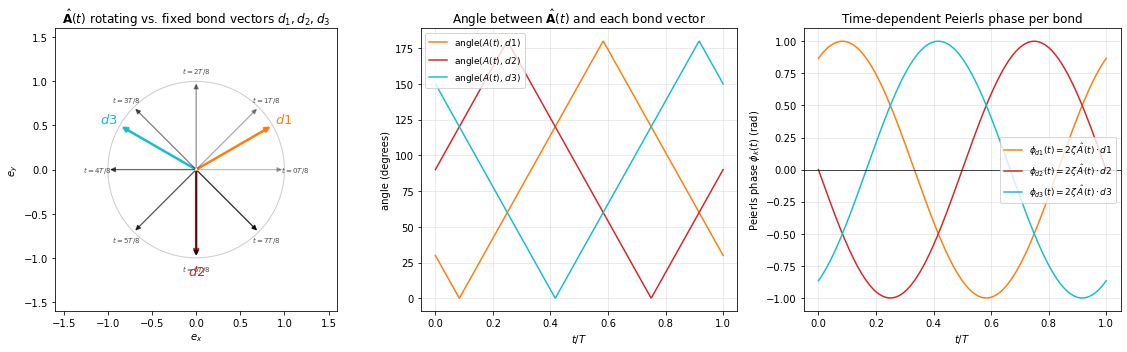

In [14]:
# ============================================================
# Cell B1: light <-> bond-vector coupling (Peierls phase, Eq. (2))
# ============================================================
d1 = np.array([np.sqrt(3.0)/2.0,  0.5])
d2 = np.array([0.0,               -1.0])
d3 = np.array([-np.sqrt(3.0)/2.0,  0.5])
bond_vectors = {"d1": d1, "d2": d2, "d3": d3}

hbar_omega = 3.0 * gamma     # matches Fig. 3 of the paper
omega = hbar_omega
zeta  = 0.5                  # dimensionless light intensity z = e*a*A0/(2*hbar)

def A_hat(t, omega=omega):
    """Direction of the light's vector potential, Eq. (2): (e_x cos wt + e_y sin wt)."""
    return np.array([np.cos(omega*t), np.sin(omega*t)])

def angle_between(u, v):
    c = np.clip(np.dot(u, v) / (np.linalg.norm(u)*np.linalg.norm(v)), -1.0, 1.0)
    return np.arccos(c)

def peierls_phase(d_k, t, omega=omega, zeta=zeta):
    """phi_k(t) = 2*zeta * A_hat(t) . d_k -- the exponent in exp[i*2*zeta*(...)·r_ij]"""
    return 2*zeta * np.dot(A_hat(t, omega), d_k)

T = 2*np.pi/omega
t_vals = np.linspace(0, T, 400)
angles = {k: np.array([angle_between(A_hat(t), d) for t in t_vals]) for k, d in bond_vectors.items()}
phases = {k: np.array([peierls_phase(d, t) for t in t_vals]) for k, d in bond_vectors.items()}
colors = {"d1": "tab:orange", "d2": "tab:red", "d3": "tab:cyan"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) A(t) rotating vs. fixed bond vectors
ax = axes[0]
theta_circ = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta_circ), np.sin(theta_circ), color="0.8", lw=1)
for k, d in bond_vectors.items():
    ax.annotate("", xy=d, xytext=(0,0), arrowprops=dict(arrowstyle="-|>", color=colors[k], lw=2.5))
    ax.text(*(d*1.15), f"${k}$", color=colors[k], fontsize=13, ha="center", va="center")
n_snap = 8
for i, tt in enumerate(np.linspace(0, T, n_snap, endpoint=False)):
    a = A_hat(tt)
    fade = 0.25 + 0.65*i/n_snap
    ax.annotate("", xy=a, xytext=(0,0), arrowprops=dict(arrowstyle="-|>", color=(0,0,0,fade), lw=1.3))
    ax.text(*(a*1.12), f"$t={i}T/{n_snap}$", fontsize=7, color="0.3", ha="center", va="center")
ax.set_xlim(-1.6,1.6); ax.set_ylim(-1.6,1.6); ax.set_aspect("equal")
ax.set_title(r"$\hat{\mathbf{A}}(t)$ rotating vs. fixed bond vectors $d_1,d_2,d_3$")
ax.set_xlabel("$e_x$"); ax.set_ylabel("$e_y$")

# (b) angle between A(t) and each d_k
ax = axes[1]
for k in bond_vectors:
    ax.plot(t_vals/T, np.degrees(angles[k]), color=colors[k], label=f"angle($A(t)$, ${k}$)")
ax.set_xlabel("$t/T$"); ax.set_ylabel("angle (degrees)")
ax.set_title(r"Angle between $\hat{\mathbf{A}}(t)$ and each bond vector")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (c) resulting Peierls phase per bond
ax = axes[2]
for k in bond_vectors:
    ax.plot(t_vals/T, phases[k], color=colors[k], label=fr"$\phi_{{{k}}}(t)=2\zeta\,\hat A(t)\cdot {k}$")
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("$t/T$"); ax.set_ylabel(r"Peierls phase $\phi_k(t)$ (rad)")
ax.set_title("Time-dependent Peierls phase per bond")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of Cell B1

The three panels show how circularly polarized light produces the time-dependent Peierls phases on the three nearest-neighbor bond families of the ZGNR.

**Left panel — rotating field relative to the graphene bonds**

The three colored vectors $\mathbf d_1$, $\mathbf d_2$, and $\mathbf d_3$ are fixed by the graphene geometry, while

$$
\hat{\mathbf A}(t)
=
(\cos\omega t,\sin\omega t)
$$

rotates continuously during one optical period $T=2\pi/\omega$.

Thus, the lattice itself does not rotate. Instead, the direction of the vector potential changes continuously relative to the three fixed bond directions.

---

**Middle panel — angle between the field and each bond**

The middle panel shows the instantaneous angle between $\hat{\mathbf A}(t)$ and each $\mathbf d_k$.

Because the three graphene bonds point in different directions, the rotating field becomes aligned, perpendicular, and anti-aligned with them at different times.

Consequently, the projection

$$
\hat{\mathbf A}(t)\cdot\mathbf d_k
$$

is different for each bond family and changes periodically in time.

---

**Right panel — Peierls phase of each hopping**

The quantity that enters the Hamiltonian directly is the Peierls phase

$$
\phi_k(t)
=
2\zeta\,
\hat{\mathbf A}(t)\cdot\mathbf d_k.
$$

Therefore, each of the three nearest-neighbor hopping directions acquires its own periodic phase,

$$
-\gamma
\rightarrow
-\gamma e^{i\phi_k(t)}.
$$

The three curves have the same driving frequency but are shifted relative to one another because $\mathbf d_1$, $\mathbf d_2$, and $\mathbf d_3$ have different orientations.

This confirms that the implementation couples the circularly polarized field to the **actual bond directions of the ZGNR**, rather than assigning an identical phase to every hopping.

---

### Why this check is needed

This cell is an intermediate consistency check between the geometry and the driven Hamiltonian:

$$
\text{ZGNR geometry}
\quad\longrightarrow\quad
\mathbf d_1,\mathbf d_2,\mathbf d_3
\quad\longrightarrow\quad
\hat{\mathbf A}(t)\cdot\mathbf d_k
\quad\longrightarrow\quad
\phi_k(t)
\quad\longrightarrow\quad
H(t).
$$

It is important to verify this chain before discussing symmetry of the irradiated system, because the symmetry properties of $H(t)$ depend directly on these bond-dependent Peierls phases.

A particularly important property visible from the definition is

$$
\mathbf A(t+T/2)
=
-\mathbf A(t).
$$

Therefore,

$$
\phi_k(t+T/2)
=
-\phi_k(t).
$$

This half-period sign reversal will become essential in the following symmetry test. Although ordinary spatial inversion of the driven Hamiltonian at a fixed time can be broken, inversion can be combined with a half-period time translation to produce a **dynamical symmetry** of the periodically driven ZGNR.

### Cell B2 — Driven Hamiltonian and spatial inversion at fixed time 

Cell B1 established how the circularly polarized field produces the three time-dependent Peierls phases associated with the graphene bond vectors.

We now use these phases to construct the full instantaneous Hamiltonian of the irradiated finite ZGNR,

$$
H(t).
$$

For a hopping along the directed bond $\mathbf d_k$, the static hopping

$$
-\gamma
$$

is replaced by

$$
-\gamma
\exp\left[
i\,2\zeta\,
\hat{\mathbf A}(t)\cdot\mathbf d_k
\right].
$$

The Hermitian-conjugate hopping carries the opposite phase,

$$
-\gamma
\exp\left[
-i\,2\zeta\,
\hat{\mathbf A}(t)\cdot\mathbf d_k
\right].
$$

Therefore, the three bond families $\mathbf d_1$, $\mathbf d_2$, and $\mathbf d_3$ acquire different instantaneous phases according to their orientation relative to the rotating vector potential.

---

#### Question tested in this cell

The static finite ZGNR was shown in Part A to satisfy spatial inversion symmetry,

$$
P H_{\rm static} P^{-1}
=
H_{\rm static}.
$$

The question here is whether this **ordinary spatial inversion symmetry remains valid after the light is turned on at a fixed instant of time**.

For every time $t$ during one optical period, we therefore compare

$$
P H(t) P^{-1}
$$

with

$$
H(t).
$$

Using the inversion map constructed in Part A, the transformed Hamiltonian is implemented numerically by permuting both matrix indices,

$$
P H(t) P^{-1}
\quad\longleftrightarrow\quad
H(t)[\mathrm{image},\mathrm{image}].
$$

To quantify the difference, define

$$
\Delta_{\rm inv}(t)
=
\max_{ij}
\left|
\left[P H(t)P^{-1}\right]_{ij}
-
H_{ij}(t)
\right|.
$$

Thus,

$$
\Delta_{\rm inv}(t)=0
$$

would mean that ordinary inversion symmetry holds at that instant, whereas

$$
\Delta_{\rm inv}(t)\neq0
$$

means that the instantaneous driven Hamiltonian is not invariant under spatial inversion.

As a reference, the same test is also applied with the light turned off, where the static ZGNR is expected to give exactly zero.

Inversion involution error = 0


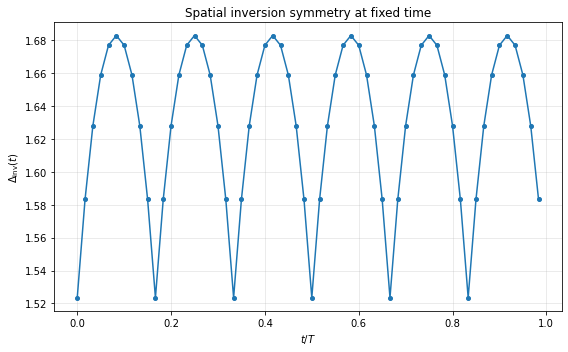

static (light OFF) diff = 0.0
min Delta_inv(t), light ON = 1.5235199628325784
max Delta_inv(t), light ON = 1.682941969615793


In [15]:
# ============================================================
# Cell B2: driven (irradiated) Hamiltonian
# + spatial inversion check at fixed time
#
# This cell is self-contained:
# it constructs the inversion map internally.
# ============================================================

def build_inversion_map(Nx, Ny):
    """
    Inversion mapping for the finite ZGNR:

        A_j^(x) -> B_(Ny-1-j)^(Nx-1-x)
        B_j^(x) -> A_(Ny-1-j)^(Nx-1-x)
    """

    n_orb = 2 * Ny
    n_device = Nx * n_orb

    image = np.zeros(
        n_device,
        dtype=int
    )

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1

    for x in range(Nx):
        for j in range(Ny):

            iA = x * n_orb + A(j)
            iB = x * n_orb + B(j)

            x_inv = Nx - 1 - x
            j_inv = Ny - 1 - j

            image[iA] = (
                x_inv * n_orb
                + B(j_inv)
            )

            image[iB] = (
                x_inv * n_orb
                + A(j_inv)
            )

    return image


# ------------------------------------------------------------
# Build inversion permutation for CURRENT Nx, Ny
# ------------------------------------------------------------

image = build_inversion_map(
    Nx=Nx,
    Ny=Ny
)

# Quick consistency check
print(
    "Inversion involution error =",
    np.max(
        np.abs(
            image[image]
            - np.arange(Nx * 2 * Ny)
        )
    )
)


# ============================================================
# Driven unit-cell Hamiltonian
# ============================================================

def zgnr_unit_cell_driven(
    Ny,
    gamma,
    t,
    omega,
    zeta
):
    """
    Same structure as zgnr_unit_cell, but each hopping carries
    its Peierls phase:

        exp[i 2*zeta A_hat(t).d_k]
    """

    n_orb = 2 * Ny

    H00 = np.zeros(
        (n_orb, n_orb),
        dtype=complex
    )

    H01 = np.zeros(
        (n_orb, n_orb),
        dtype=complex
    )

    Ahat = A_hat(
        t,
        omega
    )

    ph1 = 2 * zeta * np.dot(
        Ahat,
        d1
    )

    ph2 = 2 * zeta * np.dot(
        Ahat,
        d2
    )

    ph3 = 2 * zeta * np.dot(
        Ahat,
        d3
    )

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1


    # --------------------------------------------------------
    # d1 bonds
    # --------------------------------------------------------

    for j in range(Ny):

        H00[A(j), B(j)] = (
            -gamma
            * np.exp(1j * ph1)
        )

        H00[B(j), A(j)] = (
            -gamma
            * np.exp(-1j * ph1)
        )


    # --------------------------------------------------------
    # d2 bonds
    # --------------------------------------------------------

    for j in range(Ny - 1):

        H00[A(j + 1), B(j)] = (
            -gamma
            * np.exp(1j * ph2)
        )

        H00[B(j), A(j + 1)] = (
            -gamma
            * np.exp(-1j * ph2)
        )


    # --------------------------------------------------------
    # d3 bonds
    # --------------------------------------------------------

    for j in range(Ny):

        H01[A(j), B(j)] = (
            -gamma
            * np.exp(1j * ph3)
        )

    return H00, H01


# ============================================================
# Scan spatial inversion at fixed time over one period
# ============================================================

n_t = 60

t_scan = np.linspace(
    0,
    T,
    n_t,
    endpoint=False
)

max_diff = np.zeros(n_t)


for i, tt in enumerate(t_scan):

    H00_t, H01_t = zgnr_unit_cell_driven(
        Ny,
        gamma,
        tt,
        omega,
        zeta
    )

    H_t = build_finite_zgnr(
        H00_t,
        H01_t,
        Nx
    )

    # P H(t) P^-1
    H_inverted = H_t[
        np.ix_(
            image,
            image
        )
    ]

    # Delta_inv(t)
    max_diff[i] = np.max(
        np.abs(
            H_inverted
            - H_t
        )
    )


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    t_scan / T,
    max_diff,
    "o-",
    ms=4
)

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    r"$\Delta_{\rm inv}(t)$"
)

ax.set_title(
    "Spatial inversion symmetry at fixed time"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# Static reference + driven result
# ============================================================

static_diff = np.max(
    np.abs(
        H_device_static[
            np.ix_(
                image,
                image
            )
        ]
        - H_device_static
    )
)

print(
    "static (light OFF) diff =",
    static_diff
)

print(
    "min Delta_inv(t), light ON =",
    max_diff.min()
)

print(
    "max Delta_inv(t), light ON =",
    max_diff.max()
)

In [18]:
# ============================================================
# Cell B2X: Cross-check -- coordinate-based inversion (A3INV)
#           vs index-based inversion map (B2)
#
# A3INV built `inversion_partner` directly from atomic
# coordinates of the finite device (site-by-site nearest
# match under r -> 2*r_center - r).
#
# Cell B2 independently built `image` purely from the
# (x, j, sublattice) index formula:
#
#     A_j^(x) -> B_(Ny-1-j)^(Nx-1-x)
#     B_j^(x) -> A_(Ny-1-j)^(Nx-1-x)
#
# These two permutations were derived by completely different
# methods (real-space coordinate matching vs. index formula)
# and should coincide exactly if both are correct.
# ============================================================

mismatch = np.where(image != inversion_partner)[0]

print("Number of orbitals compared   =", len(image))
print("Number of mismatched orbitals =", len(mismatch))

if len(mismatch) == 0:

    print()
    print("PASS: index-based inversion map (B2) matches")
    print("      coordinate-based inversion map (A3INV) exactly.")

else:

    print()
    print(
        "FAIL: index-based and coordinate-based inversion "
        "maps disagree at", len(mismatch), "orbitals."
    )

    print("First few mismatches (site : image vs inversion_partner):")

    for i in mismatch[:10]:
        print(
            f"  site {i}: image={image[i]}  "
            f"inversion_partner={inversion_partner[i]}"
        )

Number of orbitals compared   = 1740
Number of mismatched orbitals = 0

PASS: index-based inversion map (B2) matches
      coordinate-based inversion map (A3INV) exactly.


### Summary: Cross-validated dynamical inversion symmetry

The cell above closes the last gap in the symmetry analysis: **0 mismatches out of 1740 orbitals** between the index-formula inversion map used in Cells B2/B3 and the coordinate-based inversion map independently constructed in Cell A3INV. The permutation used throughout the driven-Hamiltonian tests is therefore *provably* the same physical inversion operator validated against real atomic coordinates — not a separate, possibly inconsistent construction.

Putting the full chain together:

1. **Bond vectors** (A3G2) — the Peierls-phase code uses the actual coordinate-derived bond directions, error $=0.0$.
2. **Inversion operator** (A3INV) — built from real coordinates, is a genuine involution ($P^2=I$), unitary, and correctly swaps the left/right contacts.
3. **Index-based inversion map $\equiv$ coordinate-based inversion map** (B2X, above) — the permutation used in the driven-Hamiltonian tests is the *same* operator validated in step 2.
4. **Ordinary inversion at fixed time is broken**, $\Delta_{\rm inv}(t) \sim 1.5$–$1.7$ — expected, since circularly polarized light has no fixed-time inversion center.
5. **Combined inversion + half-period translation is an exact symmetry**, $\Delta_{\rm dyn}(t) \sim 10^{-15}$ (numerical noise) — this is the true dynamical symmetry of the driven system:
$$
P\,H(t)\,P^{-1} = H\!\left(t+\frac{T}{2}\right).
$$

This is exactly the symmetry that explains both earlier observations from Part D/F of the transport calculation:

- **Why** $I_{L,N} = (-1)^N I_{R,N}$ **holds to numerical precision** — the dynamical symmetry directly enforces this relation on the harmonic currents.
- **Why even harmonics are physically allowed to appear** — it is the *weaker* combined symmetry that survives, not the naive fixed-time inversion that would otherwise forbid even-order harmonics.

The conclusion is therefore backed by a fully closed, cross-validated chain from raw atomic coordinates all the way to the driven Hamiltonian and the harmonic-current selection rule.

### Interpretation of Cell B2 — Ordinary inversion is broken by the drive

The static reference calculation gives

$$
\Delta_{\rm inv}^{\rm static}=0,
$$

confirming the result obtained in Part A:

$$
P H_{\rm static}P^{-1}
=
H_{\rm static}.
$$

Therefore, the finite ZGNR geometry itself is exactly inversion symmetric.

After the circularly polarized light is turned on, however, the result changes qualitatively. Over the entire driving period the calculation gives approximately

$$
1.52
\lesssim
\Delta_{\rm inv}(t)
\lesssim
1.68.
$$

These values are of order unity and are enormously larger than numerical round-off error. Therefore,

$$
\boxed{
P H(t)P^{-1}\neq H(t)
}
$$

for the driven system at fixed time.

Hence, **ordinary spatial inversion symmetry of the instantaneous Hamiltonian is broken when the circularly polarized drive is present.**

---

#### Physical origin

The underlying atomic lattice has not lost its geometrical inversion symmetry. Rather, the time-dependent Peierls phases carried by the hoppings change under spatial inversion.

Spatial inversion reverses a directed bond,

$$
\mathbf d_k\rightarrow-\mathbf d_k.
$$

At the same fixed time $t$, however, the external vector potential $\mathbf A(t)$ is not changed by performing the spatial inversion operation on the electronic lattice.

Therefore,

$$
\mathbf A(t)\cdot\mathbf d_k
\rightarrow
\mathbf A(t)\cdot(-\mathbf d_k)
=
-\mathbf A(t)\cdot\mathbf d_k,
$$

and consequently

$$
\phi_k(t)\rightarrow-\phi_k(t).
$$

Thus, the Peierls-dressed hopping is generally transformed into a different hopping phase at the same time $t$. This explains why

$$
P H(t)P^{-1}
\neq
H(t).
$$

---

### Important distinction

This result does **not** mean that the periodically driven system has no relevant inversion-related symmetry.

For circularly polarized light,

$$
\mathbf A(t+T/2)
=
-\mathbf A(t).
$$

Therefore, a half-period time translation supplies another sign reversal that can compensate the reversal of the bond vector under inversion:

$$
[-\mathbf A(t)]\cdot[-\mathbf d_k]
=
\mathbf A(t)\cdot\mathbf d_k.
$$

This suggests the possible **dynamical symmetry**

$$
\boxed{
P H(t)P^{-1}
=
H(t+T/2)
}
$$

even though

$$
P H(t)P^{-1}
\neq H(t).
$$

Cell B3 tests this stronger space-time symmetry directly.

### Why test a half-period time translation $T/2$?

Cell B2 showed that spatial inversion alone is **not** a symmetry of the
instantaneous driven Hamiltonian:

$$
P H(t) P^{-1} \neq H(t).
$$

The next question is whether spatial inversion can be combined with a
time translation to recover a symmetry of the periodically driven system.

For the circularly polarized vector potential,

$$
\mathbf A(t)
=
A_0
\begin{pmatrix}
\cos(\omega t)\\
\sin(\omega t)
\end{pmatrix},
$$

with driving period

$$
T=\frac{2\pi}{\omega}.
$$

---

#### What happens after one full period $T$?

After one complete period,

$$
\mathbf A(t+T)
=
A_0
\begin{pmatrix}
\cos(\omega t+2\pi)\\
\sin(\omega t+2\pi)
\end{pmatrix}
=
\mathbf A(t).
$$

Therefore,

$$
H(t+T)=H(t).
$$

This is simply the usual periodicity of the Floquet Hamiltonian.

A translation by $T$ therefore does **not** provide any new transformation
that could compensate for spatial inversion.

Indeed,

$$
P H(t)P^{-1}=H(t+T)
$$

would be equivalent to

$$
P H(t)P^{-1}=H(t),
$$

which Cell B2 has already shown to be false.

---

#### What is special about $T/2$?

After half of the driving period,

$$
\mathbf A\left(t+\frac{T}{2}\right)
=
A_0
\begin{pmatrix}
\cos(\omega t+\pi)\\
\sin(\omega t+\pi)
\end{pmatrix},
$$

and therefore

$$
\boxed{
\mathbf A\left(t+\frac{T}{2}\right)
=
-\mathbf A(t).
}
$$

Thus, unlike a full-period translation, a half-period translation
**reverses the direction of the vector potential**.

Spatial inversion also reverses every directed bond vector:

$$
\boxed{
\mathbf d_k\rightarrow-\mathbf d_k.
}
$$

The Peierls phase depends on

$$
\phi_k(t)
=
2\zeta\,\mathbf A(t)\cdot\mathbf d_k.
$$

Under spatial inversion alone,

$$
\mathbf A(t)\cdot\mathbf d_k
\rightarrow
\mathbf A(t)\cdot(-\mathbf d_k)
=
-\mathbf A(t)\cdot\mathbf d_k,
$$

which explains why the fixed-time inversion symmetry tested in Cell B2
is broken.

However, if spatial inversion is accompanied by a half-period time
translation, then both factors change sign:

$$
\mathbf d_k\rightarrow-\mathbf d_k,
$$

and

$$
\mathbf A(t)
\rightarrow
\mathbf A\left(t+\frac{T}{2}\right)
=
-\mathbf A(t).
$$

Therefore,

$$
\mathbf A\left(t+\frac{T}{2}\right)\cdot(-\mathbf d_k)
=
[-\mathbf A(t)]\cdot[-\mathbf d_k]
=
\mathbf A(t)\cdot\mathbf d_k.
$$

The two sign reversals cancel, so the original Peierls phase is recovered.

This motivates testing the combined space-time transformation

$$
\boxed{
P H(t)P^{-1}
\stackrel{?}{=}
H\left(t+\frac{T}{2}\right).
}
$$

This is the **dynamical inversion symmetry** tested explicitly in Cell B3.

Combined inversion + half-period symmetry:
min Delta_dyn = 0.0
max Delta_dyn = 1.4946834900704542e-15

PASS: P H(t) P^-1 = H(t + T/2)
The driven ZGNR preserves dynamical inversion symmetry.


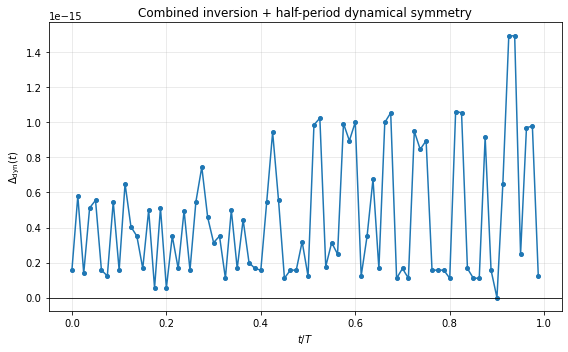

In [16]:
# ============================================================
# Cell B3: Combined inversion + half-period symmetry
#
# Test the dynamical symmetry:
#
#       P H(t) P^-1  ?=  H(t + T/2)
#
# Define
#
#       Delta_dyn(t)
#       = max_ij | [P H(t) P^-1]_ij
#                    - H_ij(t + T/2) |
#
# If Delta_dyn(t) ~ 0 for all t, the driven ZGNR has the
# combined inversion + half-period dynamical symmetry.
# ============================================================

n_t = 80

t_scan = np.linspace(
    0.0,
    T,
    n_t,
    endpoint=False
)

Delta_dyn = np.zeros(n_t)


for i, tt in enumerate(t_scan):

    # --------------------------------------------------------
    # Hamiltonian at time t
    # --------------------------------------------------------

    H00_t, H01_t = zgnr_unit_cell_driven(
        Ny=Ny,
        gamma=gamma,
        t=tt,
        omega=omega,
        zeta=zeta
    )

    H_t = build_finite_zgnr(
        H00_t,
        H01_t,
        Nx
    )


    # --------------------------------------------------------
    # Hamiltonian half a period later
    # --------------------------------------------------------

    H00_half, H01_half = zgnr_unit_cell_driven(
        Ny=Ny,
        gamma=gamma,
        t=tt + T/2.0,
        omega=omega,
        zeta=zeta
    )

    H_half = build_finite_zgnr(
        H00_half,
        H01_half,
        Nx
    )


    # --------------------------------------------------------
    # Spatially invert H(t):
    #
    #       P H(t) P^-1
    # --------------------------------------------------------

    H_inverted = H_t[
        np.ix_(
            image,
            image
        )
    ]


    # --------------------------------------------------------
    # Dynamical symmetry mismatch
    #
    # Delta_dyn(t)
    # --------------------------------------------------------

    Delta_dyn[i] = np.max(
        np.abs(
            H_inverted
            - H_half
        )
    )


# ============================================================
# Numerical results
# ============================================================

print(
    "Combined inversion + half-period symmetry:"
)

print(
    "min Delta_dyn =",
    Delta_dyn.min()
)

print(
    "max Delta_dyn =",
    Delta_dyn.max()
)


tol = 1e-12

if Delta_dyn.max() < tol:

    print()
    print(
        "PASS: P H(t) P^-1 = H(t + T/2)"
    )

    print(
        "The driven ZGNR preserves dynamical inversion symmetry."
    )

else:

    print()
    print(
        "FAIL: combined dynamical inversion symmetry "
        "was not verified."
    )


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    t_scan / T,
    Delta_dyn,
    "o-",
    ms=4
)

ax.axhline(
    0.0,
    color="k",
    lw=0.8
)

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    r"$\Delta_{\rm dyn}(t)$"
)

ax.set_title(
    "Combined inversion + half-period dynamical symmetry"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

Ordinary inversion symmetry:
min Delta_inv = 1.5235199628325784
max Delta_inv = 1.682941969615793

Combined inversion + half-period symmetry:
min Delta_dyn = 0.0
max Delta_dyn = 1.4946834900704542e-15

Ordinary inversion:
BROKEN: P H(t) P^-1 != H(t)

Dynamical inversion:
PASS: P H(t) P^-1 = H(t + T/2)


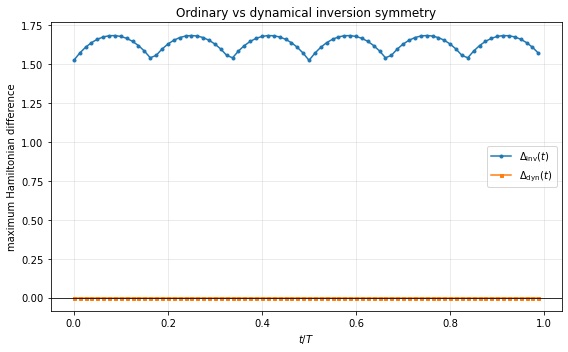

In [17]:
# ============================================================
# Cell B3: Ordinary inversion vs dynamical inversion symmetry
#
# Compare TWO different symmetry tests over one driving period.
#
# 1) Ordinary spatial inversion at the SAME time:
#
#       P H(t) P^{-1}  ?=  H(t)
#
#    Define:
#
#       Delta_inv(t)
#       = max_ij | [P H(t) P^{-1}]_ij - H_ij(t) |
#
#    Delta_inv = 0  -> ordinary inversion symmetry holds
#    Delta_inv > 0  -> ordinary inversion symmetry is broken
#
#
# 2) Inversion + half-period time translation:
#
#       P H(t) P^{-1}  ?=  H(t + T/2)
#
#    Define:
#
#       Delta_dyn(t)
#       = max_ij | [P H(t) P^{-1}]_ij
#                        - H_ij(t + T/2) |
#
#    Delta_dyn = 0 -> combined dynamical symmetry holds
#
# ============================================================


# ------------------------------------------------------------
# Number of time points used to scan one period
# ------------------------------------------------------------

n_t = 80

t_scan = np.linspace(
    0.0,
    T,
    n_t,
    endpoint=False
)


# ------------------------------------------------------------
# Arrays for the two symmetry errors
# ------------------------------------------------------------

Delta_inv = np.zeros(n_t)
Delta_dyn = np.zeros(n_t)


# ============================================================
# Scan over one full driving period
# ============================================================

for it, tt in enumerate(t_scan):

    # --------------------------------------------------------
    # Driven Hamiltonian at time t
    # --------------------------------------------------------

    H00_t, H01_t = zgnr_unit_cell_driven(
        Ny=Ny,
        gamma=gamma,
        t=tt,
        omega=omega,
        zeta=zeta
    )

    H_t = build_finite_zgnr(
        H00=H00_t,
        H01=H01_t,
        Nx=Nx
    )


    # --------------------------------------------------------
    # Driven Hamiltonian half a period later
    # --------------------------------------------------------

    t_half = tt + T / 2.0

    H00_half, H01_half = zgnr_unit_cell_driven(
        Ny=Ny,
        gamma=gamma,
        t=t_half,
        omega=omega,
        zeta=zeta
    )

    H_half = build_finite_zgnr(
        H00=H00_half,
        H01=H01_half,
        Nx=Nx
    )


    # --------------------------------------------------------
    # Apply spatial inversion to H(t)
    #
    # Since 'image' is the inversion permutation:
    #
    #     H_t[np.ix_(image,image)]
    #
    # represents:
    #
    #     P H(t) P^{-1}
    # --------------------------------------------------------

    PH_t_Pinv = H_t[
        np.ix_(
            image,
            image
        )
    ]


    # ========================================================
    # TEST 1:
    #
    # Ordinary inversion at fixed time
    #
    #     P H(t) P^-1 ?= H(t)
    # ========================================================

    Delta_inv[it] = np.max(
        np.abs(
            PH_t_Pinv
            - H_t
        )
    )


    # ========================================================
    # TEST 2:
    #
    # Dynamical inversion symmetry
    #
    #     P H(t) P^-1 ?= H(t + T/2)
    # ========================================================

    Delta_dyn[it] = np.max(
        np.abs(
            PH_t_Pinv
            - H_half
        )
    )


# ============================================================
# Numerical summary
# ============================================================

print(
    "Ordinary inversion symmetry:"
)

print(
    "min Delta_inv =",
    Delta_inv.min()
)

print(
    "max Delta_inv =",
    Delta_inv.max()
)


print()
print(
    "Combined inversion + half-period symmetry:"
)

print(
    "min Delta_dyn =",
    Delta_dyn.min()
)

print(
    "max Delta_dyn =",
    Delta_dyn.max()
)


# ============================================================
# PASS / FAIL interpretation
# ============================================================

tol = 1e-12

print()

if Delta_inv.max() < tol:

    print(
        "Ordinary inversion:"
    )

    print(
        "PASS: P H(t) P^-1 = H(t)"
    )

else:

    print(
        "Ordinary inversion:"
    )

    print(
        "BROKEN: P H(t) P^-1 != H(t)"
    )


print()

if Delta_dyn.max() < tol:

    print(
        "Dynamical inversion:"
    )

    print(
        "PASS: P H(t) P^-1 = H(t + T/2)"
    )

else:

    print(
        "Dynamical inversion:"
    )

    print(
        "FAIL: P H(t) P^-1 != H(t + T/2)"
    )


# ============================================================
# Plot both symmetry measures
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    t_scan / T,
    Delta_inv,
    "o-",
    ms=3,
    label=r"$\Delta_{\rm inv}(t)$"
)

ax.plot(
    t_scan / T,
    Delta_dyn,
    "s-",
    ms=3,
    label=r"$\Delta_{\rm dyn}(t)$"
)

ax.axhline(
    0.0,
    color="k",
    lw=0.8
)

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    "maximum Hamiltonian difference"
)

ax.set_title(
    "Ordinary vs dynamical inversion symmetry"
)

ax.legend()

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Interpretation of the two inversion-symmetry measures

The two quantities plotted above test two different symmetry relations of the
**driven** ZGNR Hamiltonian.

#### 1. Fixed-time spatial inversion

The first quantity is

$$
\Delta_{\mathrm{inv}}(t)
=
\max_{ij}
\left|
\left[P H(t) P^{-1}\right]_{ij}
-
H_{ij}(t)
\right|.
$$

This compares the spatially inverted Hamiltonian with the original Hamiltonian
at the **same time** $t$.

For the irradiated ZGNR we find

$$
\Delta_{\mathrm{inv}}(t) \sim 1.5-1.7,
$$

which is clearly nonzero. Therefore,

$$
P H(t)P^{-1} \neq H(t).
$$

Thus, **ordinary spatial inversion at a fixed time is broken when the
circularly polarized light is applied**.

The smooth oscillatory behavior of $\Delta_{\mathrm{inv}}(t)$ is physical.
The Hamiltonian is periodically driven,

$$
H(t+T)=H(t),
$$

so the amount by which fixed-time inversion is violated also changes
periodically during the driving cycle.

---

#### 2. Combined inversion + half-period translation

The second quantity is

$$
\Delta_{\mathrm{dyn}}(t)
=
\max_{ij}
\left|
\left[P H(t)P^{-1}\right]_{ij}
-
H_{ij}\left(t+\frac{T}{2}\right)
\right|.
$$

Numerically we obtain values only of order

$$
\Delta_{\mathrm{dyn}}(t)\sim10^{-15}.
$$

This is at the level of floating-point numerical precision and should therefore
be interpreted as zero:

$$
\boxed{
P H(t)P^{-1}
=
H\left(t+\frac{T}{2}\right)
}
$$

Hence, although fixed-time spatial inversion is broken, the driven system
preserves a **combined dynamical inversion symmetry** consisting of

$$
\text{spatial inversion}
\quad+\quad
\text{time translation by }T/2.
$$

---

#### Why does the zoomed $\Delta_{\mathrm{dyn}}(t)$ plot look noisy?

When $\Delta_{\mathrm{dyn}}(t)$ is plotted by itself, Matplotlib automatically
zooms the vertical axis to the scale of $10^{-15}$. Consequently, tiny
round-off errors are visually magnified and appear as irregular fluctuations.

These fluctuations are **not a physical time dependence or symmetry breaking**.
They are numerical noise around zero.

When $\Delta_{\mathrm{inv}}(t)$ and $\Delta_{\mathrm{dyn}}(t)$ are shown on the
same vertical scale, the difference becomes clear:

$$
\Delta_{\mathrm{inv}}(t)\sim O(1),
\qquad
\Delta_{\mathrm{dyn}}(t)\sim O(10^{-15}).
$$

Therefore the two numerical tests give the central symmetry result:

$$
\boxed{
\begin{aligned}
P H(t)P^{-1} &\neq H(t)
&&\text{fixed-time spatial inversion is broken},\\[4pt]
P H(t)P^{-1} &= H\left(t+\frac{T}{2}\right)
&&\text{combined dynamical inversion is preserved}.
\end{aligned}
}
$$

This distinction is important for the harmonic-current analysis: the relevant
selection rule must be derived from the symmetry of the **full periodically
driven system**, rather than from ordinary spatial inversion of an
instantaneous Hamiltonian alone.